In [1]:
from flonacomldft.utils.io_utils import (
    load_pickle_file, 
    get_project_path,
    save_pickle_file,
    load_csv_file,
)

import json
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from flonacomldft.utils.plots import set_plot_sequential_data
import matplotlib.pylab as pylab
from ase.units import kB

size=14
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_path = get_project_path() + '/1-adaptive'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

In [3]:
accs_info = []

for isomer, number_id in zip(isomers, number_ids):
    path_sims = 'results_adaptive_is{:d}_{:d}'.format(isomer, number_id)
    accs_file = '/accs_is{:d}_{:d}.csv'.format(isomer, number_id)
    #part_ratios_file = '/part_ratios_is{:d}_{:d}.csv'.format(isomer, number_id)
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    acc = load_csv_file(path_sims+accs_file, project_path)
    f = open(project_path+'/'+path_sims+args_file)
    data = json.load(f)
    data['accs'] = acc[:, 0].detach().numpy()
    accs_info.append(data)

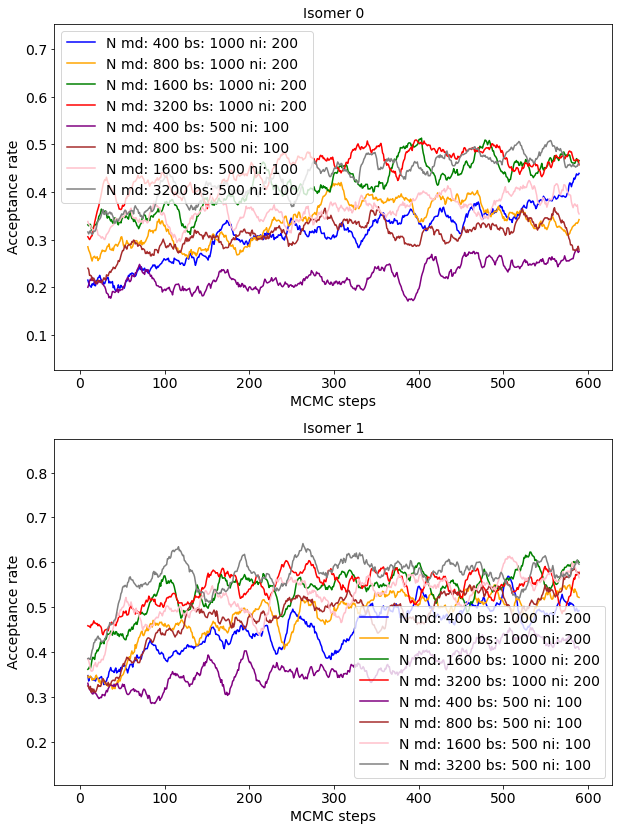

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(10, 14))

c1 = ['blue', 'orange', 'green', 'red', 'blue', 'orange', 'green', 'red']
c2 = ['purple', 'brown', 'pink', 'gray', 'purple', 'brown', 'pink', 'gray']
colors = c1 + c2

for i, acc_info in enumerate(accs_info):

    isomer_label = acc_info['isomer_label'][0]
    
    label  = 'N md: {:d} bs: {:d} ni: {:d}'.format(int(acc_info['N']*0.8),
                                                acc_info['flow_batch_size'],
                                                acc_info['flow_n_iter'])

    color_value = colors[i]
    set_plot_sequential_data(acc_info['accs'], avg=True, window_size=20, alpha=0.0, color=color_value, ax=axs[isomer_label], label=label)

    axs[isomer_label].legend()
    axs[isomer_label].set_xlabel('MCMC steps')
    axs[isomer_label].set_ylabel('Acceptance rate')
    axs[isomer_label].set_title('Isomer {:d}'.format(isomer_label))